In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures

# Cargar data preprocesada:

data_p = pd.read_csv('../Data/Processed/Flujo_Vehicular_procesado.csv', encoding='latin-1')

data_p.head()

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,VEH_PESADOS_TOTAL,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO
0,102.814804,8070.0,2586.0,2374.0,720.0,315.0,3512.0,8.0,10169.000000,328.000000,9515.0,306.9,19684.0,635.0,2014.0,1.0,201401.0,Concesionado,22PE5NACS1,San Martín
1,0.000000,24644.0,6502.0,4622.0,1654.0,3028.0,8711.0,213.0,24644.000000,795.000000,24730.0,797.7,49374.0,1592.7,2014.0,1.0,201401.0,Concesionado,04PE1SCAM1,Arequipa
2,7.211207,82139.0,17981.0,5307.0,1150.0,1737.0,5342.0,12.0,85932.622101,2851.164583,37326.0,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,Concesionado,21PE3SCRO1,Puno
3,10.000000,46944.0,16981.0,18585.0,4463.0,3058.0,19400.0,135.0,46954.000000,1514.600000,62622.0,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,Concesionado,12PE3NCRA1,Junín
4,0.000000,23831.0,4709.0,3941.0,447.0,769.0,3945.0,95.0,23831.000000,768.700000,13906.0,448.6,37737.0,1217.3,2014.0,1.0,201401.0,Concesionado,08PE3SCSC1,Cusco


In [26]:
def es_cuarentena(periodo):
    return 1 if 202003 <= periodo <= 202006 else 0

data_p['CUARENTENA'] = data_p['PERIODO'].apply(es_cuarentena)

In [27]:
data_p.columns

Index(['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',
       'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 'VEH_PESADOS_5E', 'VEH_PESADOS_6E',
       'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD',
       'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 'VEH_TOTAL', 'VEH_IMD', 'ANIO',
       'MES', 'PERIODO', 'ADMINIST', 'CODIGO_PEAJE', 'DEPARTAMENTO',
       'CUARENTENA'],
      dtype='object')

In [28]:
columns_a_entrenar = ['VEH_LIGEROS_TAR_DIF', 'VEH_LIGEROS_AUTOMOVILES', 'VEH_PESADOS__2E',  'VEH_PESADOS_3E', 'VEH_PESADOS_4E', 
'VEH_PESADOS_5E', 'VEH_PESADOS_6E', 'VEH_PESADOS_7E', 'VEH_LIGEROS_TOTAL', 'VEH_LIGEROS_IMD', 'VEH_PESADOS_TOTAL', 'VEH_PESADOS_IMD', 
'VEH_TOTAL', 'VEH_IMD']

In [29]:
data_p

,VEH_LIGEROS_TAR_DIF,VEH_LIGEROS_AUTOMOVILES,VEH_PESADOS__2E,VEH_PESADOS_3E,VEH_PESADOS_4E,VEH_PESADOS_5E,VEH_PESADOS_6E,VEH_PESADOS_7E,VEH_LIGEROS_TOTAL,VEH_LIGEROS_IMD,...,VEH_PESADOS_IMD,VEH_TOTAL,VEH_IMD,ANIO,MES,PERIODO,ADMINIST,CODIGO_PEAJE,DEPARTAMENTO,CUARENTENA
0,102.814804,8070.00,2586.0,2374.0,720.000000,315.000000,3512.000000,8.00000,10169.000000,328.000000,...,306.9,19684.0,635.0,2014.0,1.0,201401.0,Concesionado,22PE5NACS1,San Martín,0
1,0.000000,24644.00,6502.0,4622.0,1654.000000,3028.000000,8711.000000,213.00000,24644.000000,795.000000,...,797.7,49374.0,1592.7,2014.0,1.0,201401.0,Concesionado,04PE1SCAM1,Arequipa,0
2,7.211207,82139.00,17981.0,5307.0,1150.000000,1737.000000,5342.000000,12.00000,85932.622101,2851.164583,...,1204.1,153108.0,4939.0,2014.0,1.0,201401.0,Concesionado,21PE3SCRO1,Puno,0
3,10.000000,46944.00,16981.0,18585.0,4463.000000,3058.000000,19400.000000,135.00000,46954.000000,1514.600000,...,2020.1,109576.0,3534.7,2014.0,1.0,201401.0,Concesionado,12PE3NCRA1,Junín,0
4,0.000000,23831.00,4709.0,3941.0,447.000000,769.000000,3945.000000,95.00000,23831.000000,768.700000,...,448.6,37737.0,1217.3,2014.0,1.0,201401.0,Concesionado,08PE3SCSC1,Cusco,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10776,660.000000,3609.00,808.0,603.0,605.000000,2553.000000,859.000000,3.00000,4269.000000,142.300000,...,181.0,9700.0,323.3,2025.0,6.0,202506.0,No concesionado,21PE36ASIC1,Puno,0
10777,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,0.000000,0.000000,...,0.0,0.0,0.0,2025.0,6.0,202506.0,No concesionado,05PE28ASOC1,Ayacucho,0
10778,0.000000,31078.00,3209.0,965.0,290.000000,221.000000,489.000000,4.00000,31078.000000,1035.900000,...,172.6,36256.0,1208.5,2025.0,6.0,202506.0,No concesionado,20PE1NLTGD1,Piura,0
10779,0.000000,117.24,44.3,76.8,36.844361,63.640417,222.992208,2.73875,0.000000,0.000000,...,0.0,0.0,0.0,2025.0,6.0,202506.0,No concesionado,15PE16TNA1,Lima,0


In [31]:
data_p['CODIGO_PEAJE'].unique()

array(['22PE5NACS1', '04PE1SCAM1', '21PE3SCRO1', '12PE3NCRA1',
       '08PE3SCSC1', '13PE1NCMA1', '15PE1SCLA1', '20PE1NJCLS1',
       '13PE08CDS1', '15PE22CCA1', '20PE1NCBA1', '14PE04BOLS1',
       '04PE1SEFS1', '15PE1NEPS1', '15PE1NFZA1', '02PE1NHUY1',
       '11PE1SICA1', '18PE36ILO1', '11PE1SJAY1', '20PE02ALLA1',
       '21PE34BMNI1', '11PE30MNA1', '04PE34MRI1', '13PE10AMEO1',
       '14PE1NJMOC1', '18PE1SMTV1', '14PE1NMRE1', '22PE5NMYB1',
       '13PE1NPGA1', '20PE02PAI1', '18PE36APCL1', '05PE30APGR1',
       '03PE30APPR1', '04PE34APTI1', '01PE08CPRS1', '03PE30APRH1',
       '20PE1NPSA1', '17PE30CPNN1', '06PE3NPPU1', '22PE5NBPGO1',
       '12PE3SQLA1', '21PE34BSGB1', '17PE30CSLZ1', '21PE34ASLA1',
       '15PE1NASPY1', '23PE1STMS1', '04PE34AVYO1', '17PE30CUPO1',
       '01PE5NUTB1', '15PE1NVPY1', '02PE1NVSQ1', '13PE1NVIR1',
       '08PE3SACS1', '04PE1SATI1', '21PE3SAYV1', '24PE1NCCS1',
       '02PE3NCTC1', '12PE3SHUO1', '12PE22BCHO1', '14PE06ACUC1',
       '20PE1NTYL1', '21PE3SILV1'

In [67]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb

peaje = '04PE34MRI1'

data_f = data_p[data_p['CODIGO_PEAJE'] == peaje]

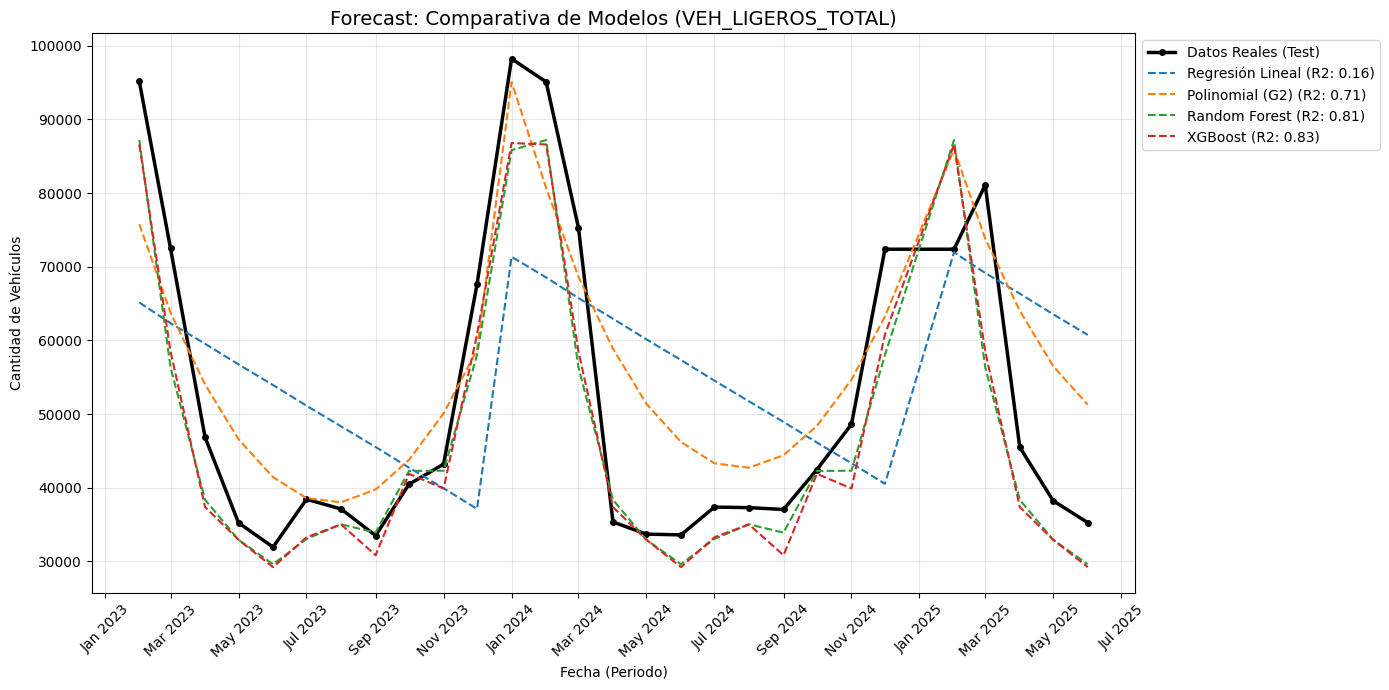


--- TABLA DE INDICADORES ---
          Modelo          MSE  R2 Score
         XGBoost 7.469349e+07  0.834369
   Random Forest 8.427573e+07  0.813120
 Polinomial (G2) 1.296795e+08  0.712438
Regresión Lineal 3.785451e+08  0.160583


In [68]:

# --- 1. PREPARACIÓN DEL ÍNDICE TEMPORAL ---
df = data_f.copy()

# Convertimos '202501.0' (float) -> 202501 (int) -> '202501' (str)
# Luego a datetime usando el formato de Año y Mes (%Y%m)
df['PERIODO'] = pd.to_datetime(df['PERIODO'].astype(int).astype(str), format='%Y%m')

# Lo fijamos como Índice y ordenamos
df = df.set_index('PERIODO')
df = df.sort_index()

# --- 2. DEFINICIÓN DE VARIABLES ---
features = ['ANIO', 'MES', 'CUARENTENA']
target = 'VEH_LIGEROS_TOTAL'

X = df[features]
y = df[target]

# --- 3. DIVISIÓN TRAIN / TEST ---
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 4. NORMALIZACIÓN (SCALING) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- 5. DEFINICIÓN DE MODELOS ---
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Polinomial (G2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

# --- 6. ENTRENAMIENTO Y EVALUACIÓN ---
resultados = []
plt.figure(figsize=(14, 7))

# Graficamos DATOS REALES
plt.plot(y_test.index, y_test, label='Datos Reales (Test)', color='black', linewidth=2.5, marker='o', markersize=4)

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "R2 Score": r2
    })
    
    # Graficar la predicción
    plt.plot(y_test.index, y_pred, label=f'{nombre} (R2: {r2:.2f})', linestyle='--')

# --- 7. FORMATEO DEL GRÁFICO ---
plt.title(f"Forecast: Comparativa de Modelos ({target})", fontsize=14)
plt.xlabel("Fecha (Periodo)")
plt.ylabel("Cantidad de Vehículos")

# Mejorar la lectura de las fechas en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Una marca cada 2 meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Formato: Ene 2025
plt.xticks(rotation=45)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Leyenda fuera del gráfico para no tapar
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. RESULTADOS FINALES ---
df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Score", ascending=False)
print("\n--- TABLA DE INDICADORES ---")
print(df_resultados.to_string(index=False))

In [69]:
data_f = data_p[(data_p['CODIGO_PEAJE'] == peaje) & (data_p['CUARENTENA'] != 1)]

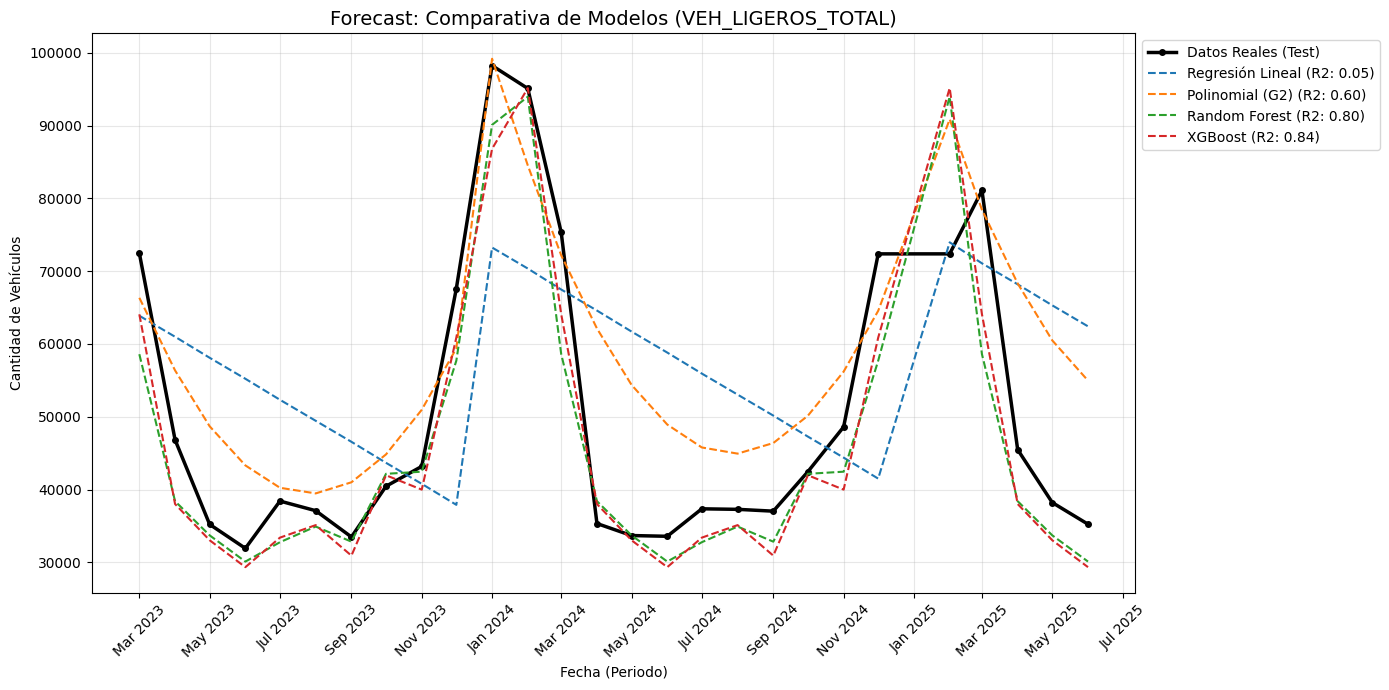


--- TABLA DE INDICADORES ---
          Modelo          MSE  R2 Score
         XGBoost 6.387737e+07  0.838982
   Random Forest 7.930209e+07  0.800100
 Polinomial (G2) 1.594040e+08  0.598184
Regresión Lineal 3.768798e+08  0.049983


In [70]:
# --- 1. PREPARACIÓN DEL ÍNDICE TEMPORAL ---
df = data_f.copy()

# Convertimos '202501.0' (float) -> 202501 (int) -> '202501' (str)
# Luego a datetime usando el formato de Año y Mes (%Y%m)
df['PERIODO'] = pd.to_datetime(df['PERIODO'].astype(int).astype(str), format='%Y%m')

# Lo fijamos como Índice y ordenamos
df = df.set_index('PERIODO')
df = df.sort_index()

# --- 2. DEFINICIÓN DE VARIABLES ---
features = ['ANIO', 'MES', 'CUARENTENA']
target = 'VEH_LIGEROS_TOTAL'

X = df[features]
y = df[target]

# --- 3. DIVISIÓN TRAIN / TEST ---
train_size = int(len(df) * 0.8)
X_train_raw, X_test_raw = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# --- 4. NORMALIZACIÓN (SCALING) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# --- 5. DEFINICIÓN DE MODELOS ---
modelos = {
    "Regresión Lineal": LinearRegression(),
    "Polinomial (G2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
}

# --- 6. ENTRENAMIENTO Y EVALUACIÓN ---
resultados = []
plt.figure(figsize=(14, 7))

# Graficamos DATOS REALES
plt.plot(y_test.index, y_test, label='Datos Reales (Test)', color='black', linewidth=2.5, marker='o', markersize=4)

for nombre, modelo in modelos.items():
    # Entrenar
    modelo.fit(X_train, y_train)
    
    # Predecir
    y_pred = modelo.predict(X_test)
    
    # Calcular Métricas
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    resultados.append({
        "Modelo": nombre,
        "MSE": mse,
        "R2 Score": r2
    })
    
    # Graficar la predicción
    plt.plot(y_test.index, y_pred, label=f'{nombre} (R2: {r2:.2f})', linestyle='--')

# --- 7. FORMATEO DEL GRÁFICO ---
plt.title(f"Forecast: Comparativa de Modelos ({target})", fontsize=14)
plt.xlabel("Fecha (Periodo)")
plt.ylabel("Cantidad de Vehículos")

# Mejorar la lectura de las fechas en el eje X
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=2)) # Una marca cada 2 meses
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Formato: Ene 2025
plt.xticks(rotation=45)

plt.legend(loc='upper left', bbox_to_anchor=(1, 1)) # Leyenda fuera del gráfico para no tapar
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- 8. RESULTADOS FINALES ---
df_resultados = pd.DataFrame(resultados).sort_values(by="R2 Score", ascending=False)
print("\n--- TABLA DE INDICADORES ---")
print(df_resultados.to_string(index=False))